In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import missingno as msno
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn import tree
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

In [2]:
train= pd.read_csv('taxi_train.csv')
test= pd.read_csv('taxi_test.csv')

In [3]:
train.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [4]:
train.shape

(1458644, 11)

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


In [6]:
train.describe()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06
mean,1.534950e+00,1.664530e+00,-7.397349e+01,4.075092e+01,-7.397342e+01,4.075180e+01,9.594923e+02
std,4.987772e-01,1.314242e+00,7.090186e-02,3.288119e-02,7.064327e-02,3.589056e-02,5.237432e+03
min,1.000000e+00,0.000000e+00,-1.219333e+02,3.435970e+01,-1.219333e+02,3.218114e+01,1.000000e+00
25%,1.000000e+00,1.000000e+00,-7.399187e+01,4.073735e+01,-7.399133e+01,4.073588e+01,3.970000e+02
50%,2.000000e+00,1.000000e+00,-7.398174e+01,4.075410e+01,-7.397975e+01,4.075452e+01,6.620000e+02
75%,2.000000e+00,2.000000e+00,-7.396733e+01,4.076836e+01,-7.396301e+01,4.076981e+01,1.075000e+03
max,2.000000e+00,9.000000e+00,-6.133553e+01,5.188108e+01,-6.133553e+01,4.392103e+01,3.526282e+06


In [7]:
train['pickup_datetime']

0          2016-03-14 17:24:55
1          2016-06-12 00:43:35
2          2016-01-19 11:35:24
3          2016-04-06 19:32:31
4          2016-03-26 13:30:55
                  ...         
1458639    2016-04-08 13:31:04
1458640    2016-01-10 07:35:15
1458641    2016-04-22 06:57:41
1458642    2016-01-05 15:56:26
1458643    2016-04-05 14:44:25
Name: pickup_datetime, Length: 1458644, dtype: object

In [8]:
train['pickup_datetime'] = pd.to_datetime(train['pickup_datetime'], errors='coerce')
train['pickup_date'] = train['pickup_datetime'].dt.date
train['pickup_hour'] = train['pickup_datetime'].dt.hour
train['pickup_day_of_week'] = train['pickup_datetime'].dt.dayofweek
train['dropoff_datetime'] = pd.to_datetime(train['dropoff_datetime'], errors='coerce')
train['dropoff_date'] = train['dropoff_datetime'].dt.date
train['dropoff_hour'] = train['dropoff_datetime'].dt.hour
train['dropoff_day_of_week'] = train['dropoff_datetime'].dt.dayofweek
train['trip_time_diff'] = (train['dropoff_datetime'] - train['pickup_datetime']).dt.total_seconds()

In [9]:
train['euclidean_distance'] = np.sqrt(
    (train['dropoff_longitude'] - train['pickup_longitude'])**2 +
    (train['dropoff_latitude'] - train['pickup_latitude'])**2
)
def haversine_np(lon1, lat1, lon2, lat2):
    R = 6371  
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c
train['distance_km'] = haversine_np(
    train['pickup_longitude'], train['pickup_latitude'],
    train['dropoff_longitude'], train['dropoff_latitude']
)

In [10]:
train['speed_kmh'] = (train['distance_km'] / (train['trip_duration'] / 3600)).replace([np.inf, -np.inf], np.nan)
train['rush_hour'] = train['pickup_hour'].isin([7,8,9,16,17,18]).astype(int)
train['same_day_trip'] = (train['pickup_date'] == train['dropoff_date']).astype(int)

<Axes: xlabel='trip_duration', ylabel='Count'>

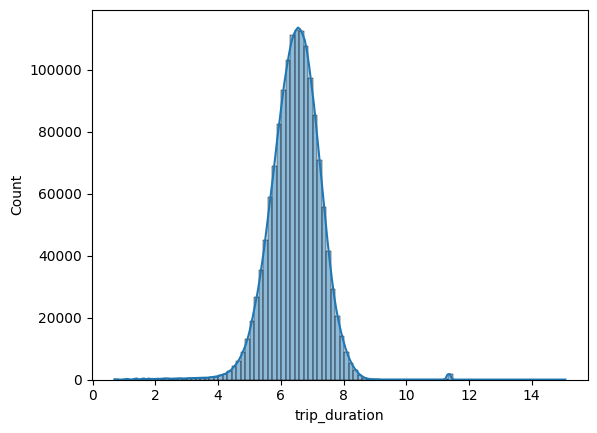

In [11]:
sns.histplot(np.log1p(train['trip_duration']), bins=100, kde=True)

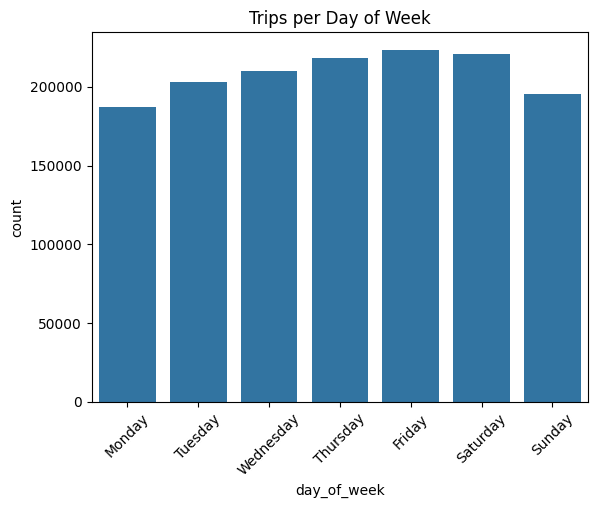

In [12]:
train['day_of_week'] = train['pickup_datetime'].dt.day_name()
sns.countplot(x='day_of_week', data=train, order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.title("Trips per Day of Week")
plt.xticks(rotation=45)
plt.show()

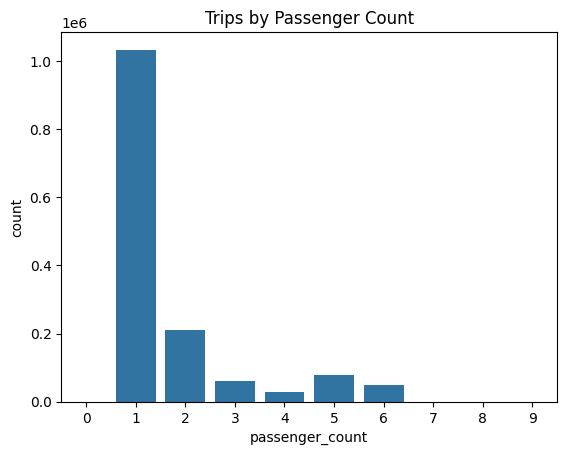

In [13]:
sns.countplot(x='passenger_count', data=train)
plt.title("Trips by Passenger Count")
plt.show()

C:\Users\nadia\AppData\Local\Temp\ipykernel_13700\2795161587.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='pickup_hour', data=train, palette='viridis')


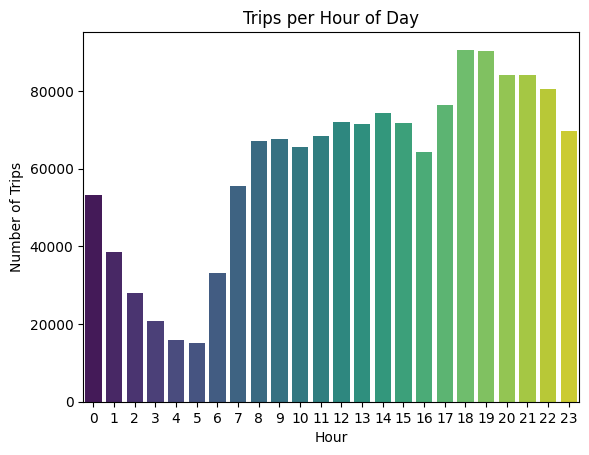

In [14]:
sns.countplot(x='pickup_hour', data=train, palette='viridis')
plt.title("Trips per Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Trips")
plt.show()

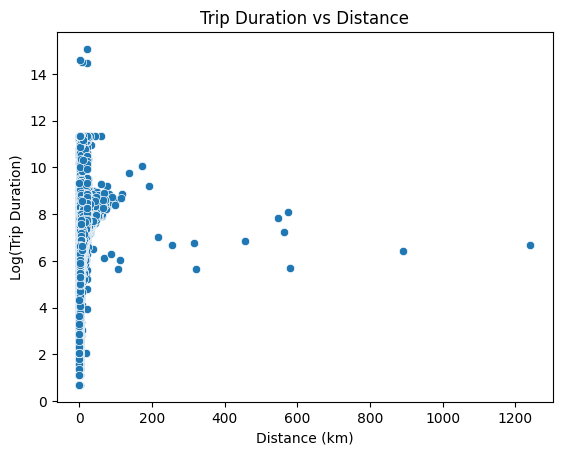

In [15]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2*R*np.arcsin(np.sqrt(a))
train['distance_km'] = haversine(
    train['pickup_latitude'], train['pickup_longitude'],
    train['dropoff_latitude'], train['dropoff_longitude']
)
sns.scatterplot(x='distance_km', y=np.log1p(train['trip_duration']), data=train)
plt.title("Trip Duration vs Distance")
plt.xlabel("Distance (km)")
plt.ylabel("Log(Trip Duration)")
plt.show()

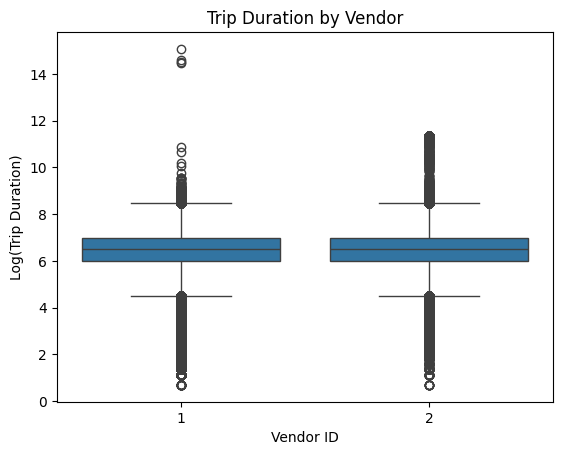

In [16]:
sns.boxplot(x='vendor_id', y=np.log1p(train['trip_duration']), data=train)
plt.title("Trip Duration by Vendor")
plt.xlabel("Vendor ID")
plt.ylabel("Log(Trip Duration)")
plt.show()

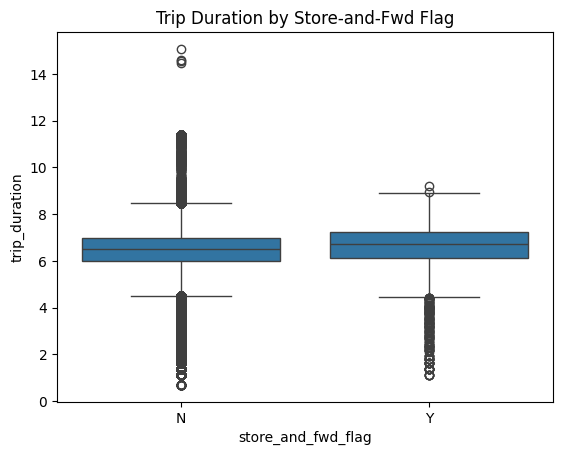

In [17]:
sns.boxplot(x='store_and_fwd_flag', y=np.log1p(train['trip_duration']), data=train)
plt.title("Trip Duration by Store-and-Fwd Flag")
plt.show()

In [18]:
# --- Data Processing ---

In [19]:
train.isna().sum()

id                     0
vendor_id              0
pickup_datetime        0
dropoff_datetime       0
passenger_count        0
pickup_longitude       0
pickup_latitude        0
dropoff_longitude      0
dropoff_latitude       0
store_and_fwd_flag     0
trip_duration          0
pickup_date            0
pickup_hour            0
pickup_day_of_week     0
dropoff_date           0
dropoff_hour           0
dropoff_day_of_week    0
trip_time_diff         0
euclidean_distance     0
distance_km            0
speed_kmh              0
rush_hour              0
same_day_trip          0
day_of_week            0
dtype: int64

In [20]:
train.duplicated().sum()

0

In [21]:
train.select_dtypes(include='object').columns

Index(['id', 'store_and_fwd_flag', 'pickup_date', 'dropoff_date',
       'day_of_week'],
      dtype='object')

In [22]:
le = LabelEncoder()
for col in train.select_dtypes(include='object').columns:
    train[col] = le.fit_transform(train[col].astype(str))

In [23]:
train.head(5)

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,...,dropoff_date,dropoff_hour,dropoff_day_of_week,trip_time_diff,euclidean_distance,distance_km,speed_kmh,rush_hour,same_day_trip,day_of_week
0,1049145,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,0,...,73,17,0,455.0,0.017680,1.498521,11.856428,1,1,1
1,867655,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,0,...,163,0,6,663.0,0.020456,1.805507,9.803659,0,1,3
2,1406899,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,0,...,18,12,1,2124.0,0.059934,6.385098,10.822201,0,1,5
3,1278209,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,0,...,96,19,2,429.0,0.013438,1.485498,12.465721,0,1,6
4,796092,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,0,...,85,13,5,435.0,0.010690,1.188588,9.836594,0,1,2


In [24]:
print(train.nunique())

id                     1458644
vendor_id                    2
pickup_datetime        1380222
dropoff_datetime       1380377
passenger_count             10
pickup_longitude         23047
pickup_latitude          45245
dropoff_longitude        33821
dropoff_latitude         62519
store_and_fwd_flag           2
trip_duration             7417
pickup_date                182
pickup_hour                 24
pickup_day_of_week           7
dropoff_date               183
dropoff_hour                24
dropoff_day_of_week          7
trip_time_diff            7417
euclidean_distance     1437906
distance_km            1452288
speed_kmh              1452587
rush_hour                    2
same_day_trip                2
day_of_week                  7
dtype: int64


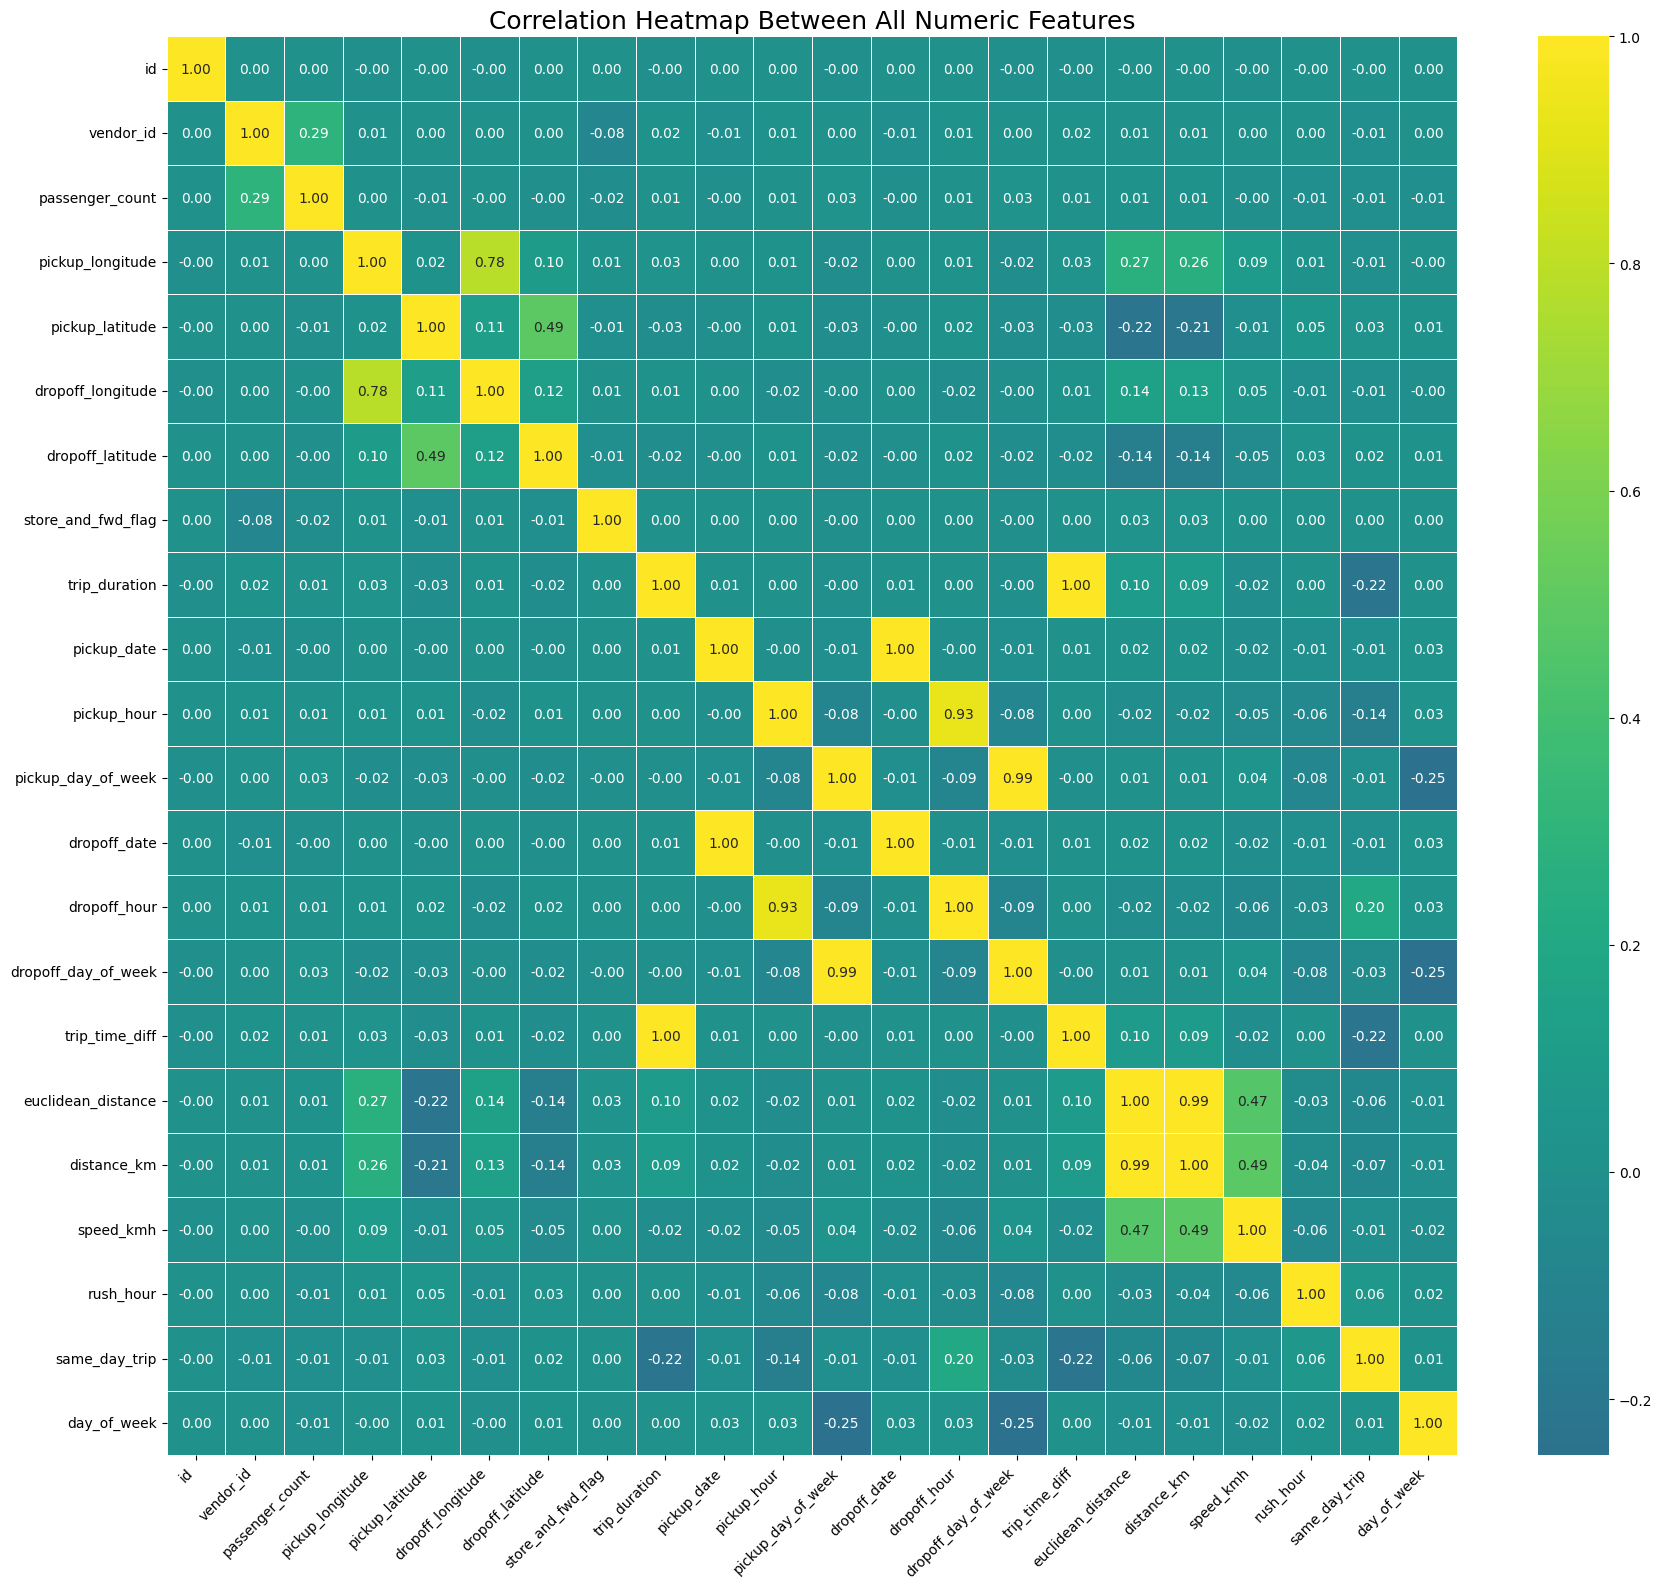

In [25]:
corr = train.corr(numeric_only=True)
plt.figure(figsize=(18, 16))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="viridis", center=0, linewidths=0.5)
plt.title("Correlation Heatmap Between All Numeric Features", fontsize=18)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [26]:
train.drop(['id', 'pickup_datetime', 'dropoff_datetime',
 'pickup_date', 'dropoff_date', 'store_and_fwd_flag','euclidean_distance',
 'trip_time_diff', 'same_day_trip', 'day_of_week'],axis=1,inplace=True)

In [29]:
X=train.drop(['trip_duration'],axis=1)
y=train['trip_duration']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [30]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((1166915, 13), (291729, 13), (1166915,), (291729,))

In [31]:
# Build Linear Regression Model
lr=LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [32]:
pred_train=lr.predict(X_train)
mean_squared_error(y_train,pred_train)

31238005.48305058

In [33]:
pred_test=lr.predict(X_test)
mean_squared_error(y_test,pred_test)

10152505.506970953

In [34]:
print("R² train:", r2_score(y_train,pred_train))
print("R² test:", r2_score(y_test,pred_test))

R² train: 0.012717222898152802
R² test: 0.0414787284594158


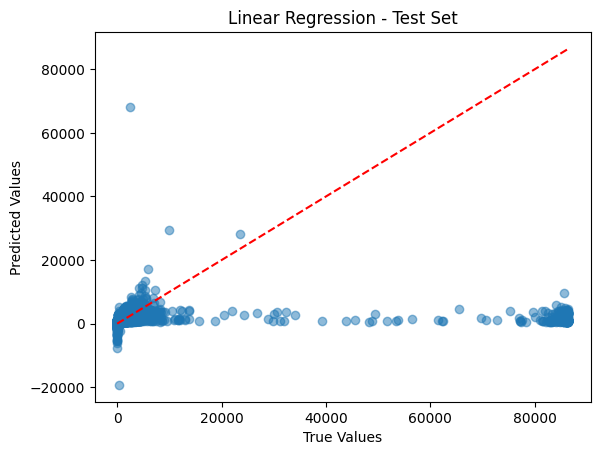

In [35]:
plt.scatter(y_test, pred_test, alpha=0.5)
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Linear Regression - Test Set")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') 
plt.show()

In [36]:
# Build Decision Tree Model

In [37]:
clf = tree.DecisionTreeRegressor(max_depth=4)
clf = clf.fit(X_train, y_train)

[Text(0.47115384615384615, 0.9, 'x[11] <= 0.52\nsquared_error = 31640383.29\nsamples = 1166915\nvalue = 959.274'),
 Text(0.25, 0.7, 'x[10] <= 16.093\nsquared_error = 3707760746.417\nsamples = 9131\nvalue = 15390.346'),
 Text(0.3605769230769231, 0.8, 'True  '),
 Text(0.15384615384615385, 0.5, 'x[10] <= 0.383\nsquared_error = 1952334421.454\nsamples = 9129\nvalue = 14794.965'),
 Text(0.07692307692307693, 0.3, 'x[10] <= 0.255\nsquared_error = 36355437.709\nsamples = 7639\nvalue = 1076.525'),
 Text(0.038461538461538464, 0.1, 'squared_error = 22505079.914\nsamples = 7572\nvalue = 891.387'),
 Text(0.11538461538461539, 0.1, 'squared_error = 1159991462.362\nsamples = 67\nvalue = 21999.896'),
 Text(0.23076923076923078, 0.3, 'x[11] <= 0.013\nsquared_error = 5863778129.524\nsamples = 1490\nvalue = 85127.284'),
 Text(0.19230769230769232, 0.1, 'squared_error = 7924026289.0\nsamples = 2\nvalue = 2138595.0'),
 Text(0.2692307692307692, 0.1, 'squared_error = 185743779.19\nsamples = 1488\nvalue = 82367.

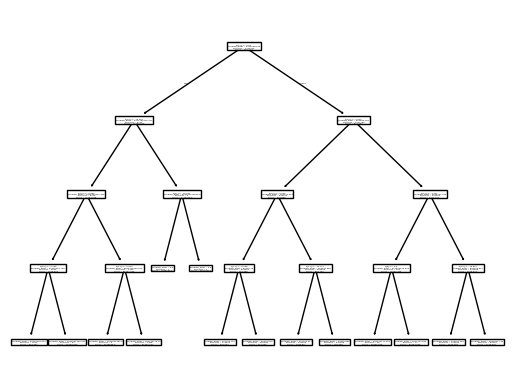

In [38]:
tree.plot_tree(clf)

In [39]:
#Feature Importance Analysis
importances = clf.feature_importances_
feature_importance = pd.Series(importances, index=X_train.columns)
important_features = feature_importance.sort_values(ascending=False)
print(important_features.head(10))

distance_km          0.661246
speed_kmh            0.303436
pickup_longitude     0.034800
dropoff_hour         0.000517
vendor_id            0.000000
passenger_count      0.000000
pickup_latitude      0.000000
dropoff_longitude    0.000000
dropoff_latitude     0.000000
pickup_hour          0.000000
dtype: float64


In [40]:
pred_clf=clf.predict(X_train)

In [41]:
np.sqrt(mean_squared_error(y_train,pred_clf))

804.7845554170882

In [42]:
pred_clf=clf.predict(X_test)

In [43]:
np.sqrt(mean_squared_error(y_test,pred_clf))

829.4327613317975

In [45]:
# Build Random Forest Model

In [46]:
rf=RandomForestRegressor(n_estimators=100)

In [47]:
rf.fit(X_train,y_train)

RandomForestRegressor()

In [59]:
rf_pred_train = rf.predict(X_train)

In [60]:
mean_squared_error(y_train,rf_pred_train)

1148361.1326595633

In [61]:
rf_pred_test=rf.predict(X_test)

In [62]:
mean_squared_error(y_test,rf_pred_test)

119401.33495273947

In [63]:
print("Train mean:", y_train.mean())
print("Test mean:", y_test.mean())

Train mean: 959.2735854796622
Test mean: 960.3670221335555


In [53]:
# Build XGBoost Model

In [47]:
xgb = XGBRegressor( n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42)
xgb.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [48]:
xgb_pred_train = xgb.predict(X_train)

In [49]:
mean_squared_error(y_train,xgb_pred_train)

102253.87469752568

In [51]:
xgb_pred_test=xgb.predict(X_test)

In [52]:
mean_squared_error(y_test,xgb_pred_test)

287213.37888070603

In [53]:
print("R² train:", r2_score(y_train, xgb_pred_train))
print("R² test:", r2_score(y_test, xgb_pred_test))

R² train: 0.9967682361602783
R² test: 0.9728835225105286


In [54]:
test.head()

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag
0,id3004672,1,2016-06-30 23:59:58,1,-73.988129,40.732029,-73.990173,40.756680,N
1,id3505355,1,2016-06-30 23:59:53,1,-73.964203,40.679993,-73.959808,40.655403,N
2,id1217141,1,2016-06-30 23:59:47,1,-73.997437,40.737583,-73.986160,40.729523,N
3,id2150126,2,2016-06-30 23:59:41,1,-73.956070,40.771900,-73.986427,40.730469,N
4,id1598245,1,2016-06-30 23:59:33,1,-73.970215,40.761475,-73.961510,40.755890,N


In [55]:
test.info()   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 625134 entries, 0 to 625133
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  625134 non-null  object 
 1   vendor_id           625134 non-null  int64  
 2   pickup_datetime     625134 non-null  object 
 3   passenger_count     625134 non-null  int64  
 4   pickup_longitude    625134 non-null  float64
 5   pickup_latitude     625134 non-null  float64
 6   dropoff_longitude   625134 non-null  float64
 7   dropoff_latitude    625134 non-null  float64
 8   store_and_fwd_flag  625134 non-null  object 
dtypes: float64(4), int64(2), object(3)
memory usage: 42.9+ MB


In [56]:
test.describe()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude
count,625134.000000,625134.000000,625134.000000,625134.000000,625134.000000,625134.000000
mean,1.534884,1.661765,-73.973614,40.750927,-73.973458,40.751816
std,0.498782,1.311293,0.073389,0.029848,0.072565,0.035824
min,1.000000,0.000000,-121.933128,37.389587,-121.933327,36.601322
25%,1.000000,1.000000,-73.991852,40.737392,-73.991318,40.736000
50%,2.000000,1.000000,-73.981743,40.754093,-73.979774,40.754543
75%,2.000000,2.000000,-73.967400,40.768394,-73.963013,40.769852
max,2.000000,9.000000,-69.248917,42.814938,-67.496796,48.857597


In [57]:
test.shape

(625134, 9)

In [58]:
test['pickup_datetime'] = pd.to_datetime(test['pickup_datetime'], errors='coerce')
test['pickup_date'] = test['pickup_datetime'].dt.date
test['pickup_hour'] = test['pickup_datetime'].dt.hour
test['pickup_day_of_week'] = test['pickup_datetime'].dt.dayofweek
test['rush_hour'] = test['pickup_hour'].isin([7,8,9,16,17,18]).astype(int)

In [59]:
test['euclidean_distance'] = np.sqrt(
    (test['dropoff_longitude'] - test['pickup_longitude'])**2 +
    (test['dropoff_latitude'] - test['pickup_latitude'])**2
)
def haversine_np(lon1, lat1, lon2, lat2):
    R = 6371  
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c
test['distance_km'] = haversine_np(
    test['pickup_longitude'], test['pickup_latitude'],
    test['dropoff_longitude'], test['dropoff_latitude']
)

In [60]:
test.columns

Index(['id', 'vendor_id', 'pickup_datetime', 'passenger_count',
       'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'store_and_fwd_flag', 'pickup_date', 'pickup_hour',
       'pickup_day_of_week', 'rush_hour', 'euclidean_distance', 'distance_km'],
      dtype='object')

In [61]:
test.select_dtypes(include='object').columns

Index(['id', 'store_and_fwd_flag', 'pickup_date'], dtype='object')

In [62]:
le = LabelEncoder()
for col in test.select_dtypes(include='object').columns:
    test[col] = le.fit_transform(test[col].astype(str))

In [63]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 625134 entries, 0 to 625133
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   id                  625134 non-null  int32         
 1   vendor_id           625134 non-null  int64         
 2   pickup_datetime     625134 non-null  datetime64[ns]
 3   passenger_count     625134 non-null  int64         
 4   pickup_longitude    625134 non-null  float64       
 5   pickup_latitude     625134 non-null  float64       
 6   dropoff_longitude   625134 non-null  float64       
 7   dropoff_latitude    625134 non-null  float64       
 8   store_and_fwd_flag  625134 non-null  int32         
 9   pickup_date         625134 non-null  int32         
 10  pickup_hour         625134 non-null  int32         
 11  pickup_day_of_week  625134 non-null  int32         
 12  rush_hour           625134 non-null  int32         
 13  euclidean_distance  625134 no

In [64]:
test_ids = test['id']     

In [65]:
test.drop(['pickup_date','pickup_longitude','pickup_latitude','dropoff_longitude','dropoff_latitude',
'euclidean_distance'], axis=1, inplace=True)

In [66]:
features = ['vendor_id','passenger_count','pickup_hour','pickup_day_of_week','rush_hour','distance_km']
train_sample = train.sample(frac=0.2, random_state=42) 
X_train = train_sample[features]
y_train = train_sample['trip_duration']
X_test = test[features]

In [67]:
#clear memory
import gc
del train
del test
gc.collect()

12693

In [70]:
clf = tree.DecisionTreeRegressor(max_depth=4)
clf = clf.fit(X_train, y_train)

In [71]:
y_pred = clf.predict(X_test)

In [72]:
submission = pd.DataFrame({
    "id": test_ids,
    "trip_duration": y_pred.astype(int)
})

In [73]:
submission

,id,trip_duration
0,469364,879
1,547621,879
2,190107,607
3,335483,1356
4,249509,367
...,...,...
625129,470064,367
625130,578497,1356
625131,401488,1844
625132,216304,3007


In [74]:
submission.to_csv("submission.csv", index=False)